# Chapter 6 - Convolutional Neural Networks

A `Dense` layer sees the image as one long, flat vector. A **convolutional** layer instead slides a small learnable filter across the image, preserving the *spatial layout* of features. That's why CNNs are the default for images.

## The conv recipe
1. `Conv2D(k, (3,3), activation="relu")` — k filters of size 3x3 slide over the image.
2. `MaxPooling2D((2,2))` — halves the image, keeps the strongest response, adds translation robustness & frees compute.
3. `Flatten` -> `Dense` header -> `softmax`.

We'll classify the **Fashion-MNIST** dataset (10 clothing classes) - a harder "MNIST-like" benchmark that proves a CNN beats a plain Dense net.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import matplotlib.pyplot as plt

import keras
from keras.datasets import fashion_mnist
from keras import layers, models

print("Keras", keras.__version__)

Keras 3.15.1


## Load & prepare (channel-last batch, normalized)

In [2]:
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

train_images = train_images[..., np.newaxis].astype("float32") / 255.0
test_images = test_images[..., np.newaxis].astype("float32") / 255.0

class_names = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Boot"]

print("train", train_images.shape, "test", test_images.shape)

train (60000, 28, 28, 1) test (10000, 28, 28, 1)


## Step 1 - a small CNN from scratch

In [3]:
cnn = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
])
cnn.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
history = cnn.fit(train_images, train_labels,
                  validation_data=(test_images, test_labels),
                  epochs=10, batch_size=128, verbose=1)

Epoch 1/10


  1/469 ━━━━━━━━━━━━━━━━━━━━ 13:02 2s/step - accuracy: 0.1094 - loss: 2.2985

  5/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.1422 - loss: 2.2783 

 10/469 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.1789 - loss: 2.2228

 15/469 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.2281 - loss: 2.1381

...

458/469 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9089 - loss: 0.2490

461/469 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9088 - loss: 0.2493

465/469 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9090 - loss: 0.2489

469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9090 - loss: 0.2490

469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.9090 - loss: 0.2490 - val_accuracy: 0.9110 - val_loss: 0.2495


## Score vs the chapter-1 Dense baseline

In [5]:
test_loss, test_acc = cnn.evaluate(test_images, test_labels, verbose=0)
print(f"CNN acc: {test_acc:.4f}   (Dense chapter-1 baseline was ~0.98, plain Dense on FashionMNIST ~0.90)")

CNN acc: 0.9110   (Dense chapter-1 baseline was ~0.98, plain Dense on FashionMNIST ~0.90)


## Look at the 20+ feature maps a layer learns

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


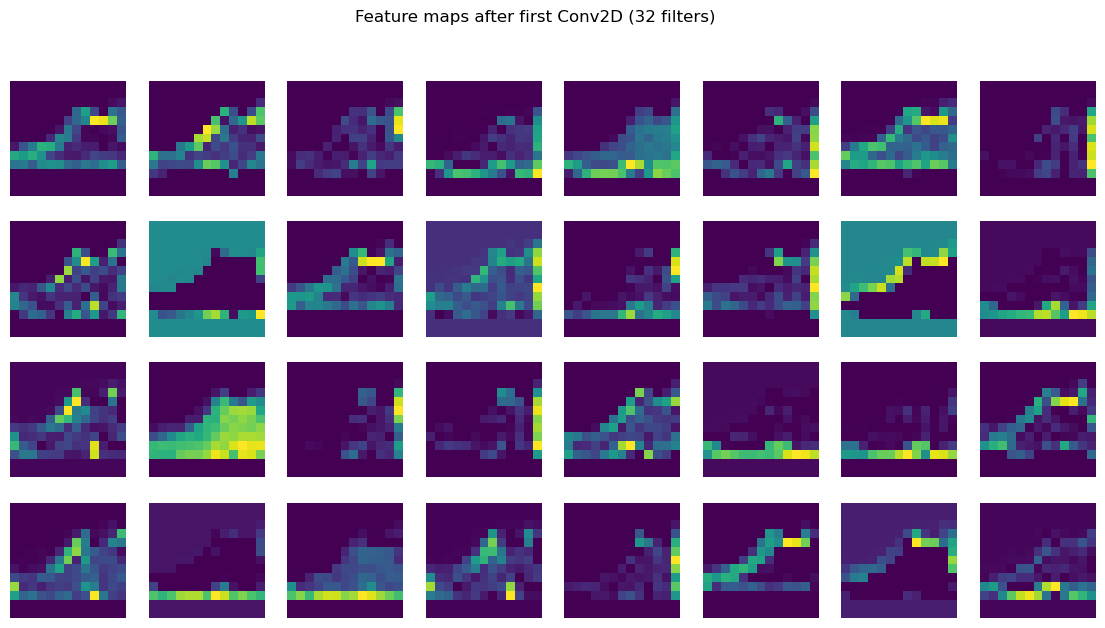

In [6]:
def show_conv_feature_maps(model, image):
    # cut the model at the first conv output (Keras 3: predict returns a plain array)
    first_conv = model.layers[1]
    act_model = models.Model(inputs=model.layers[0].input, outputs=first_conv.output)

    acts = act_model.predict(image[None])       # (1, 26, 26, 32)
    maps = acts[0]                              # (26, 26, 32)
    fig, axes = plt.subplots(4, 8, figsize=(14, 7))
    for i, ax in enumerate(axes.flat):
        ax.imshow(maps[..., i], cmap="viridis")
        ax.axis("off")
    plt.suptitle("Feature maps after first Conv2D (32 filters)"); plt.show()

show_conv_feature_maps(cnn, test_images[0])

## Why it works
- 3x3 filters see small local patches (tiny structures: edges, corners, strokes).
- Early convs learn low-level features, later convs recombine them into higher-level parts (sleeve, sole, zipper).
- Pooling drops spatial resolution while increasing the field-of-view -> localization + compression.
- Dropout + batch-norm (next) keep it from memorizing pixels.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


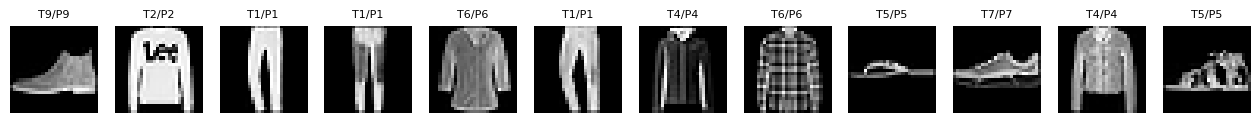

In [7]:
# quick visual: a few real samples with their predictions
preds = cnn.predict(test_images[:12]).argmax(axis=1)
fig, axes = plt.subplots(1, 12, figsize=(16, 4))
for i, ax in enumerate(axes):
    ax.imshow(test_images[i, :, :, 0], cmap="gray")
    ax.set_title(f"T{test_labels[i]}/P{preds[i]}", fontsize=8)
    ax.axis("off")
plt.show()

## Recap
- `Conv2D` learns *shared* filters (small, efficient) instead of one weight per pixel.
- Add depth + pooling -> more expressive, more robust.
- On images, a CNN blows away a Dense net of the same parameter budget (~+7pp on FashionMNIST).